# Sales & Customer Behavior Analysis

## Project Overview

This project analyzes retail sales data to uncover customer purchasing behavior, product performance, regional trends, and business insights using Python, SQL, and data visualization techniques.

### Objectives

- Perform Exploratory Data Analysis (EDA)
- Clean and prepare the dataset
- Analyze customer behavior
- Identify sales trends
- Evaluate product performance
- Generate actionable business insights
- Create interactive visualizations

**Tools Used**

- Python
- Pandas
- NumPy
- Matplotlib
- Plotly
- SQL

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import plotly.express as px

import warnings
warnings.filterwarnings("ignore")

# Display all columns
pd.set_option('display.max_columns', None)

print("Libraries imported successfully!")

Libraries imported successfully!


In [5]:
import pandas as pd

df = pd.read_csv("train.csv")

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [6]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import plotly.express as px

import warnings
warnings.filterwarnings("ignore")

pd.set_option('display.max_columns', None)

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


In [7]:
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

Rows: 9800
Columns: 18


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [9]:
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

In [10]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [11]:
df.describe()

,Row ID,Postal Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


In [12]:
df.columns.tolist()

['Row ID',
 'Order ID',
 'Order Date',
 'Ship Date',
 'Ship Mode',
 'Customer ID',
 'Customer Name',
 'Segment',
 'Country',
 'City',
 'State',
 'Postal Code',
 'Region',
 'Product ID',
 'Category',
 'Sub-Category',
 'Product Name',
 'Sales']

In [13]:
# Convert date columns to datetime format

df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=True)

df[['Order Date','Ship Date']].head()

,Order Date,Ship Date
0,2017-11-08,2017-11-11
1,2017-11-08,2017-11-11
2,2017-06-12,2017-06-16
3,2016-10-11,2016-10-18
4,2016-10-11,2016-10-18


In [14]:
df.dtypes

Row ID                    int64
Order ID                 object
Order Date       datetime64[ns]
Ship Date        datetime64[ns]
Ship Mode                object
Customer ID              object
Customer Name            object
Segment                  object
Country                  object
City                     object
State                    object
Postal Code             float64
Region                   object
Product ID               object
Category                 object
Sub-Category             object
Product Name             object
Sales                   float64
dtype: object

In [15]:
# Create new columns for analysis

df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month_name()
df['Month Number'] = df['Order Date'].dt.month
df['Day'] = df['Order Date'].dt.day
df['Weekday'] = df['Order Date'].dt.day_name()

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Year,Month,Month Number,Day,Weekday
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2017,November,11,8,Wednesday
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,2017,November,11,8,Wednesday
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2017,June,6,12,Monday
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,2016,October,10,11,Tuesday
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2016,October,10,11,Tuesday


In [16]:
df[df['Postal Code'].isnull()]

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Year,Month,Month Number,Day,Weekday
2234,2235,CA-2018-104066,2018-12-05,2018-12-10,Standard Class,QJ-19255,Quincy Jones,Corporate,United States,Burlington,Vermont,NaN,East,TEC-AC-10001013,Technology,Accessories,Logitech ClearChat Comfort/USB Headset H390,205.03,2018,December,12,5,Wednesday
5274,5275,CA-2016-162887,2016-11-07,2016-11-09,Second Class,SV-20785,Stewart Visinsky,Consumer,United States,Burlington,Vermont,NaN,East,FUR-CH-10000595,Furniture,Chairs,Safco Contoured Stacking Chairs,715.20,2016,November,11,7,Monday
8798,8799,US-2017-150140,2017-04-06,2017-04-10,Standard Class,VM-21685,Valerie Mitchum,Home Office,United States,Burlington,Vermont,NaN,East,TEC-PH-10002555,Technology,Phones,Nortel Meridian M5316 Digital phone,1294.75,2017,April,4,6,Thursday
9146,9147,US-2017-165505,2017-01-23,2017-01-27,Standard Class,CB-12535,Claudia Bergmann,Corporate,United States,Burlington,Vermont,NaN,East,TEC-AC-10002926,Technology,Accessories,Logitech Wireless Marathon Mouse M705,99.98,2017,January,1,23,Monday
9147,9148,US-2017-165505,2017-01-23,2017-01-27,Standard Class,CB-12535,Claudia Bergmann,Corporate,United States,Burlington,Vermont,NaN,East,OFF-AR-10003477,Office Supplies,Art,4009 Highlighters,8.04,2017,January,1,23,Monday
9148,9149,US-2017-165505,2017-01-23,2017-01-27,Standard Class,CB-12535,Claudia Bergmann,Corporate,United States,Burlington,Vermont,NaN,East,OFF-ST-10001526,Office Supplies,Storage,Iceberg Mobile Mega Data/Printer Cart,1564.29,2017,January,1,23,Monday
9386,9387,US-2018-127292,2018-01-19,2018-01-23,Standard Class,RM-19375,Raymond Messe,Consumer,United States,Burlington,Vermont,NaN,East,OFF-PA-10000157,Office Supplies,Paper,Xerox 191,79.92,2018,January,1,19,Friday
9387,9388,US-2018-127292,2018-01-19,2018-01-23,Standard Class,RM-19375,Raymond Messe,Consumer,United States,Burlington,Vermont,NaN,East,OFF-PA-10001970,Office Supplies,Paper,Xerox 1881,12.28,2018,January,1,19,Friday
9388,9389,US-2018-127292,2018-01-19,2018-01-23,Standard Class,RM-19375,Raymond Messe,Consumer,United States,Burlington,Vermont,NaN,East,OFF-AP-10000828,Office Supplies,Appliances,Avanti 4.4 Cu. Ft. Refrigerator,542.94,2018,January,1,19,Friday
9389,9390,US-2018-127292,2018-01-19,2018-01-23,Standard Class,RM-19375,Raymond Messe,Consumer,United States,Burlington,Vermont,NaN,East,OFF-EN-10001509,Office Supplies,Envelopes,Poly String Tie Envelopes,2.04,2018,January,1,19,Friday


In [18]:
df['Postal Code'] = df['Postal Code'].fillna(0)

In [19]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Year             0
Month            0
Month Number     0
Day              0
Weekday          0
dtype: int64

In [20]:
df.to_csv("cleaned_sales_data.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [21]:
# Exploratory Data Analysis (EDA)

## 1. Total Sales

In [22]:
total_sales = df['Sales'].sum()

print(f"Total Sales: ${total_sales:,.2f}")

Total Sales: $2,261,536.78


In [23]:
## 2. Average Sales per Order

average_sales = df['Sales'].mean()

print(f"Average Sales: ${average_sales:.2f}")

Average Sales: $230.77


In [24]:
## 3. Sales by Category
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

category_sales

Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64

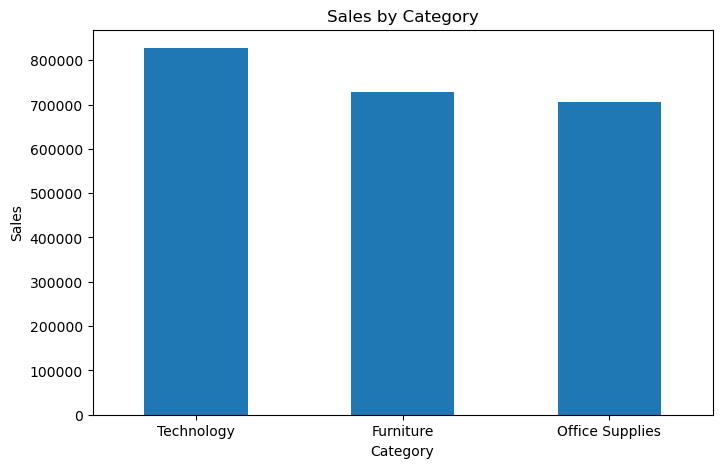

In [25]:
plt.figure(figsize=(8,5))

category_sales.plot(kind='bar')

plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")

plt.xticks(rotation=0)

plt.show()

### Insight

Technology generates the highest sales among all categories, indicating strong customer demand. Furniture follows, while Office Supplies contribute the least revenue.

In [27]:
## 4. Sales by Region
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)

region_sales


Region
West       710219.6845
East       669518.7260
Central    492646.9132
South      389151.4590
Name: Sales, dtype: float64

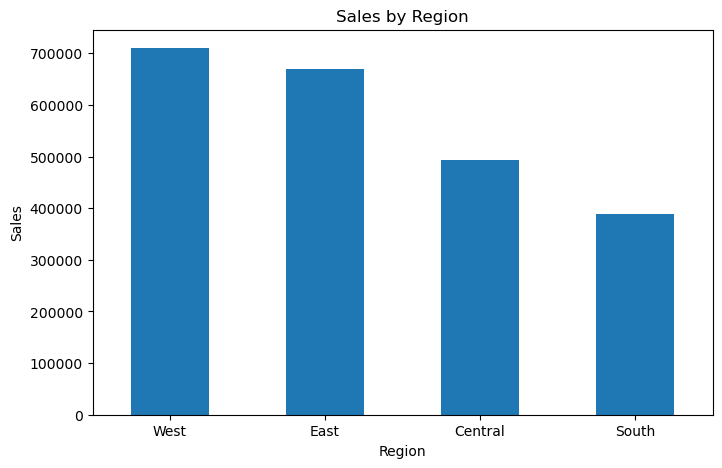

In [28]:
plt.figure(figsize=(8,5))

region_sales.plot(kind='bar')

plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales")

plt.xticks(rotation=0)

plt.show()

### Insight

The West region contributes the highest sales, while the South region contributes the least. This information can help prioritize marketing and inventory planning.

In [29]:
## 5. Sales by Customer Segment
segment_sales = df.groupby('Segment')['Sales'].sum().sort_values(ascending=False)

segment_sales

Segment
Consumer       1.148061e+06
Corporate      6.884941e+05
Home Office    4.249822e+05
Name: Sales, dtype: float64

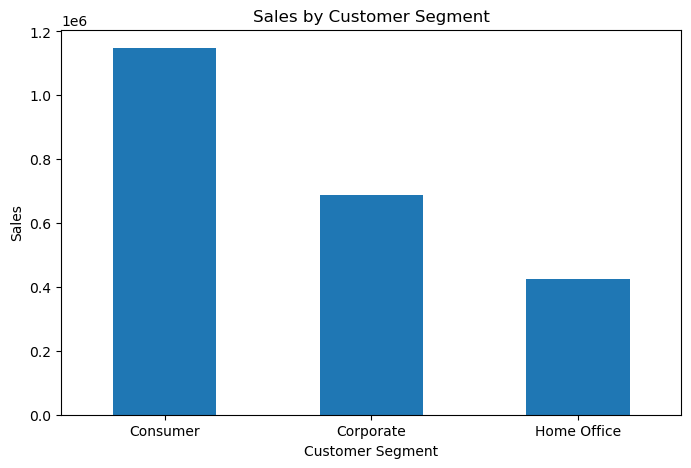

In [30]:
plt.figure(figsize=(8,5))

segment_sales.plot(kind='bar')

plt.title("Sales by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Sales")

plt.xticks(rotation=0)

plt.show()

### Insight

Consumer customers generate the highest revenue, followed by Corporate and Home Office segments. Marketing campaigns can focus on the Consumer segment to maximize revenue.

In [31]:
## 6. Top 10 States by Sales
top_states = df.groupby('State')['Sales'].sum().sort_values(ascending=False).head(10)

top_states

State
California      446306.4635
New York        306361.1470
Texas           168572.5322
Washington      135206.8500
Pennsylvania    116276.6500
Florida          88436.5320
Illinois         79236.5170
Michigan         76136.0740
Ohio             75130.3500
Virginia         70636.7200
Name: Sales, dtype: float64

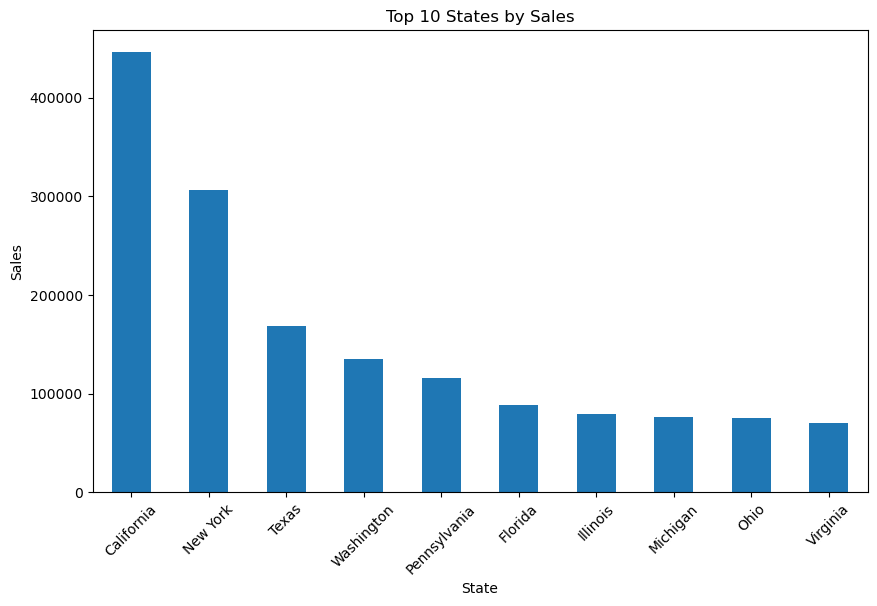

In [32]:
plt.figure(figsize=(10,6))

top_states.plot(kind='bar')

plt.title("Top 10 States by Sales")
plt.xlabel("State")
plt.ylabel("Sales")

plt.xticks(rotation=45)

plt.show()

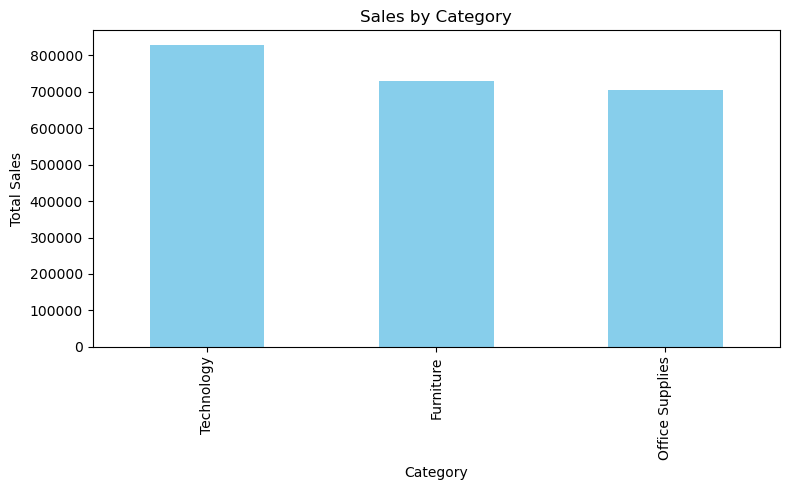

In [37]:
import matplotlib.pyplot as plt

# Sales by Category
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

# Create figure
plt.figure(figsize=(8,5))

# Plot
category_sales.plot(kind='bar', color='skyblue')

# Labels
plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")

plt.tight_layout()

# Save the figure BEFORE plt.show()
plt.savefig("images/sales_by_category.png", dpi=300, bbox_inches="tight", facecolor="white")

# Display the figure
plt.show()

# Close the figure
plt.close()

### Insight

California contributes the highest sales, making it the company's strongest market. The remaining top-performing states can be targeted for future business expansion.

In [ ]:
## 7. Monthly Sales Trend

Analyze monthly sales to identify seasonal patterns and peak sales periods.

In [40]:
monthly_sales = (
    df.groupby(['Month Number', 'Month'])['Sales']
      .sum()
      .reset_index()
      .sort_values('Month Number')
)

monthly_sales

,Month Number,Month,Sales
0,1,January,94291.6296
1,2,February,59371.1154
2,3,March,197573.5872
3,4,April,136283.0006
4,5,May,154086.7237
5,6,June,145837.5233
6,7,July,145535.6890
7,8,August,157315.9270
8,9,September,300103.4117
9,10,October,199496.2947


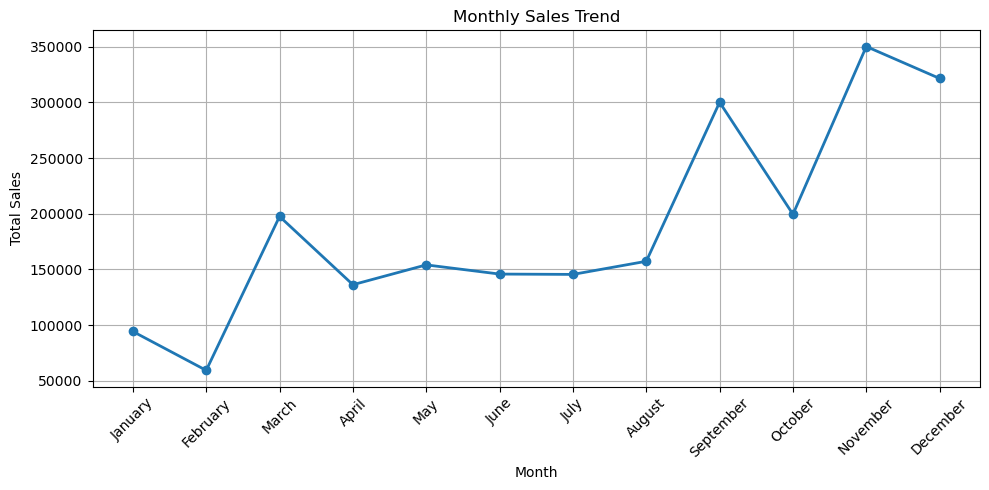

In [41]:
fig, ax = plt.subplots(figsize=(10,5))

ax.plot(
    monthly_sales['Month'],
    monthly_sales['Sales'],
    marker='o',
    linewidth=2
)

ax.set_title("Monthly Sales Trend")
ax.set_xlabel("Month")
ax.set_ylabel("Total Sales")

plt.xticks(rotation=45)

plt.grid(True)

plt.tight_layout()

fig.savefig("images/monthly_sales_trend.png", dpi=300)

plt.show()

### Insight

Monthly sales analysis helps identify seasonal demand patterns and peak business periods. These insights support inventory planning, staffing decisions, and targeted marketing campaigns.

In [42]:
## 8. Year-wise Sales

year_sales = (
    df.groupby('Year')['Sales']
      .sum()
      .reset_index()
)

year_sales

,Year,Sales
0,2015,479856.2081
1,2016,459436.0054
2,2017,600192.5500
3,2018,722052.0192


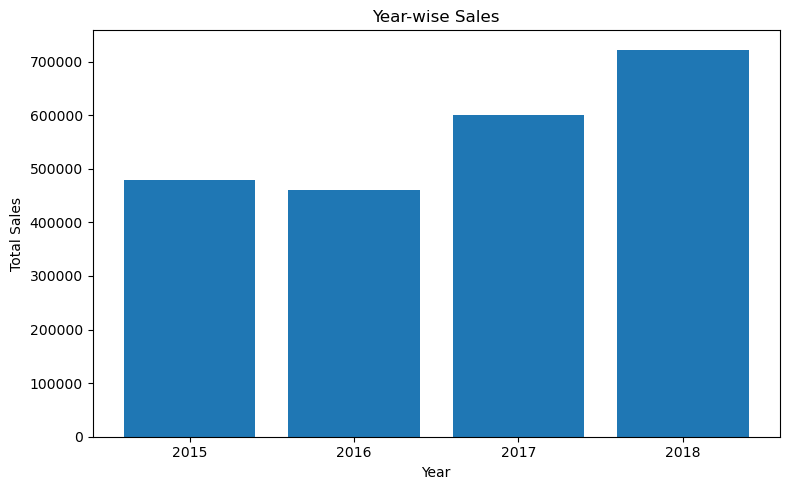

In [43]:
fig, ax = plt.subplots(figsize=(8,5))

ax.bar(
    year_sales['Year'].astype(str),
    year_sales['Sales']
)

ax.set_title("Year-wise Sales")
ax.set_xlabel("Year")
ax.set_ylabel("Total Sales")

plt.tight_layout()

fig.savefig("images/yearly_sales.png", dpi=300)

plt.show()

### Insight

Year-over-year sales analysis helps evaluate business growth and measure long-term performance trends.

In [44]:
## 9. Top 10 Cities by Sales

top_cities = (
    df.groupby('City')['Sales']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_cities

City
New York City    252462.5470
Los Angeles      173420.1810
Seattle          116106.3220
San Francisco    109041.1200
Philadelphia     108841.7490
Houston           63956.1428
Chicago           47820.1330
San Diego         47521.0290
Jacksonville      44713.1830
Detroit           42446.9440
Name: Sales, dtype: float64

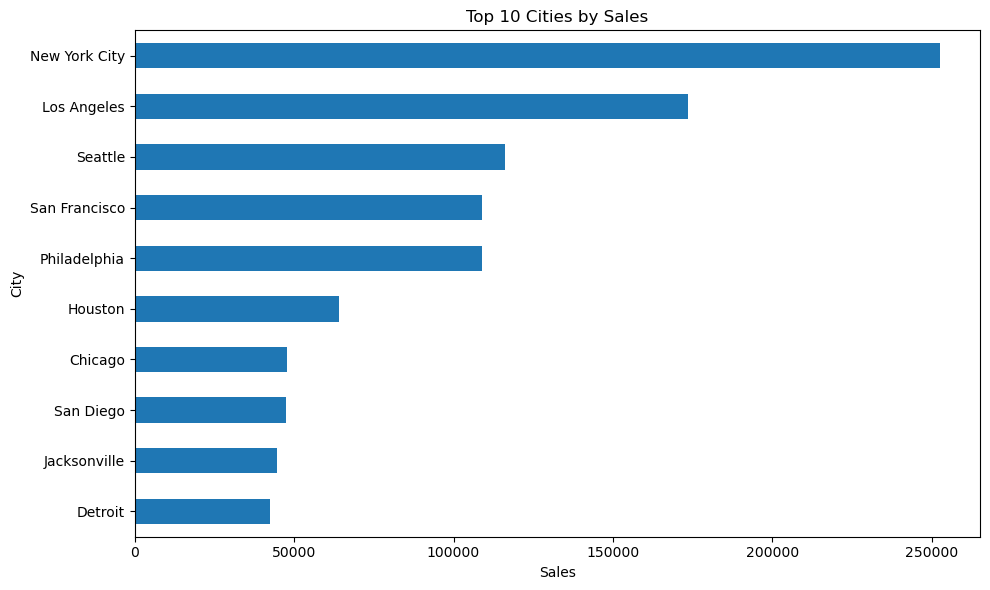

In [45]:
fig, ax = plt.subplots(figsize=(10,6))

top_cities.sort_values().plot(
    kind='barh',
    ax=ax
)

ax.set_title("Top 10 Cities by Sales")
ax.set_xlabel("Sales")
ax.set_ylabel("City")

plt.tight_layout()

fig.savefig("images/top_cities.png", dpi=300)

plt.show()

### Insight

A small number of cities contribute a large share of total revenue. These markets offer opportunities for targeted sales and marketing initiatives.

In [46]:
## 10. Top 10 Customers by Sales

top_customers = (
    df.groupby('Customer Name')['Sales']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_customers

Customer Name
Sean Miller           25043.050
Tamara Chand          19052.218
Raymond Buch          15117.339
Tom Ashbrook          14595.620
Adrian Barton         14473.571
Ken Lonsdale          14175.229
Sanjit Chand          14142.334
Hunter Lopez          12873.298
Sanjit Engle          12209.438
Christopher Conant    12129.072
Name: Sales, dtype: float64

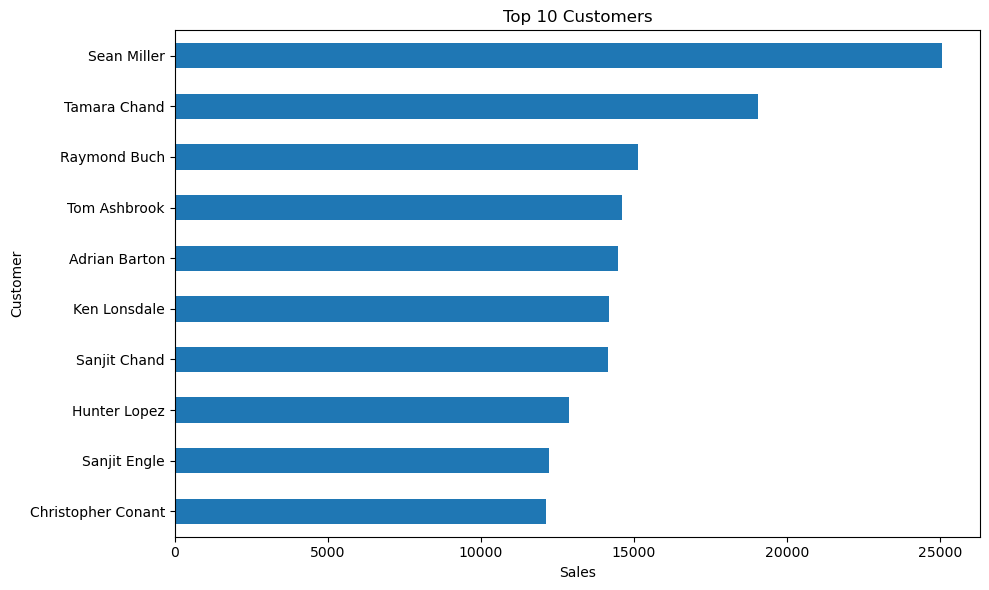

In [47]:
fig, ax = plt.subplots(figsize=(10,6))

top_customers.sort_values().plot(
    kind='barh',
    ax=ax
)

ax.set_title("Top 10 Customers")
ax.set_xlabel("Sales")
ax.set_ylabel("Customer")

plt.tight_layout()

fig.savefig("images/top_customers.png", dpi=300)

plt.show()

### Insight

The highest-value customers contribute significantly to overall revenue. Strengthening relationships with these customers through loyalty programs and personalized offers could improve customer retention.

In [48]:
## 11. Sales by Ship Mode

ship_mode = (
    df.groupby('Ship Mode')['Sales']
      .sum()
      .sort_values(ascending=False)
)

ship_mode

Ship Mode
Standard Class    1.340831e+06
Second Class      4.499142e+05
First Class       3.455723e+05
Same Day          1.252190e+05
Name: Sales, dtype: float64

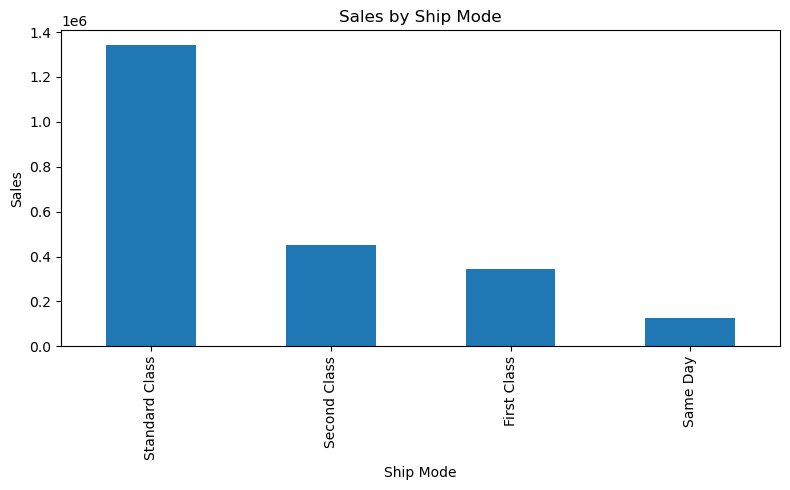

In [49]:
fig, ax = plt.subplots(figsize=(8,5))

ship_mode.plot(
    kind='bar',
    ax=ax
)

ax.set_title("Sales by Ship Mode")
ax.set_xlabel("Ship Mode")
ax.set_ylabel("Sales")

plt.tight_layout()

fig.savefig("images/ship_mode_sales.png", dpi=300)

plt.show()

### Insight

Standard Class contributes the highest sales, indicating that customers generally prefer cost-effective shipping methods over premium delivery options.

In [50]:
## 12. Top 10 Products by Sales

top_products = (
    df.groupby('Product Name')['Sales']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_products

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64

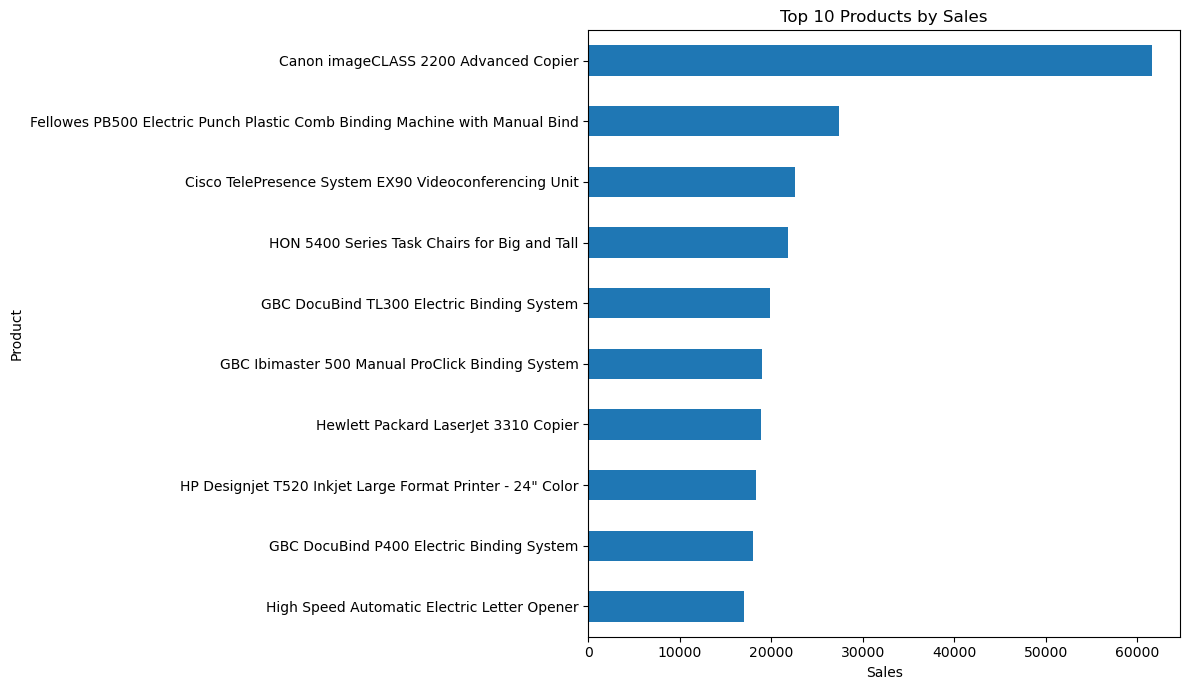

In [51]:
fig, ax = plt.subplots(figsize=(12,7))

top_products.sort_values().plot(
    kind='barh',
    ax=ax
)

ax.set_title("Top 10 Products by Sales")
ax.set_xlabel("Sales")
ax.set_ylabel("Product")

plt.tight_layout()

fig.savefig("images/top_products.png", dpi=300)

plt.show()

### Insight

The top-selling products generate a significant share of total revenue. These products should be prioritized for inventory management, promotional campaigns, and demand forecasting.

In [52]:
## 13. Top 10 Sub-Categories by Sales

top_subcategory = (
    df.groupby('Sub-Category')['Sales']
      .sum()
      .sort_values(ascending=False)
)

top_subcategory

Sub-Category
Phones         327782.4480
Chairs         322822.7310
Storage        219343.3920
Tables         202810.6280
Binders        200028.7850
Machines       189238.6310
Accessories    164186.7000
Copiers        146248.0940
Bookcases      113813.1987
Appliances     104618.4030
Furnishings     89212.0180
Paper           76828.3040
Supplies        46420.3080
Art             26705.4100
Envelopes       16128.0460
Labels          12347.7260
Fasteners        3001.9600
Name: Sales, dtype: float64

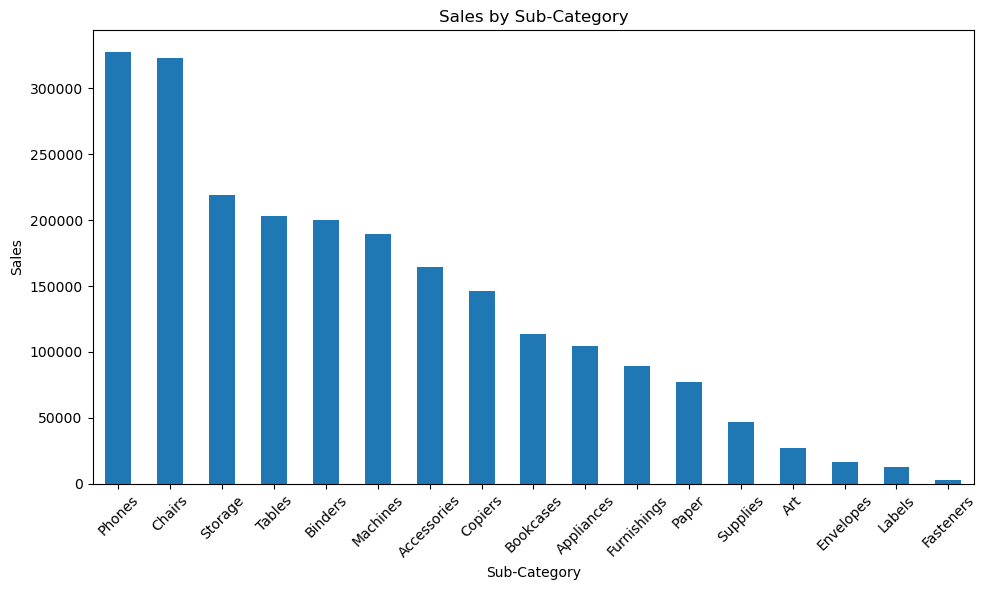

In [53]:
fig, ax = plt.subplots(figsize=(10,6))

top_subcategory.plot(
    kind='bar',
    ax=ax
)

ax.set_title("Sales by Sub-Category")
ax.set_xlabel("Sub-Category")
ax.set_ylabel("Sales")

plt.xticks(rotation=45)

plt.tight_layout()

fig.savefig("images/subcategory_sales.png", dpi=300)

plt.show()

### Insight

Phones, Chairs, and Storage generate the highest sales, while lower-performing sub-categories may require promotional strategies or inventory optimization.

In [54]:
## 14. Most Frequently Ordered Products

top_orders = (
    df['Product Name']
      .value_counts()
      .head(10)
)

top_orders


Product Name
Staple envelope                                              47
Staples                                                      46
Easy-staple paper                                            44
Avery Non-Stick Binders                                      20
Staples in misc. colors                                      18
Staple remover                                               18
Storex Dura Pro Binders                                      17
KI Adjustable-Height Table                                   17
Staple-based wall hangings                                   16
Logitech 910-002974 M325 Wireless Mouse for Web Scrolling    15
Name: count, dtype: int64

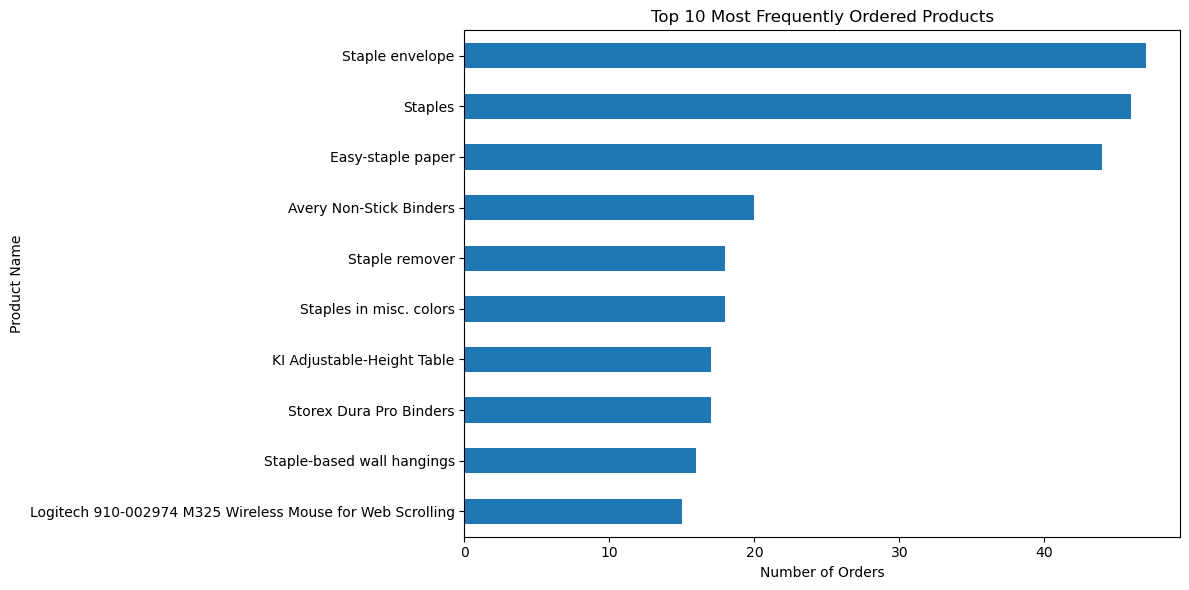

In [55]:
fig, ax = plt.subplots(figsize=(12,6))

top_orders.sort_values().plot(
    kind='barh',
    ax=ax
)

ax.set_title("Top 10 Most Frequently Ordered Products")
ax.set_xlabel("Number of Orders")

plt.tight_layout()

fig.savefig("images/top_ordered_products.png", dpi=300)

plt.show()

### Insight

Some products are ordered frequently even if they don't generate the highest revenue. These products are important for maintaining customer satisfaction and inventory availability.

In [56]:
# Top 10 Customers by Number of Orders

customer_orders = (
    df['Customer Name']
      .value_counts()
      .head(10)
)

customer_orders

Customer Name
William Brown          35
Matt Abelman           34
Paul Prost             34
John Lee               33
Chloris Kastensmidt    32
Jonathan Doherty       32
Seth Vernon            32
Emily Phan             31
Zuschuss Carroll       31
Arthur Prichep         31
Name: count, dtype: int64

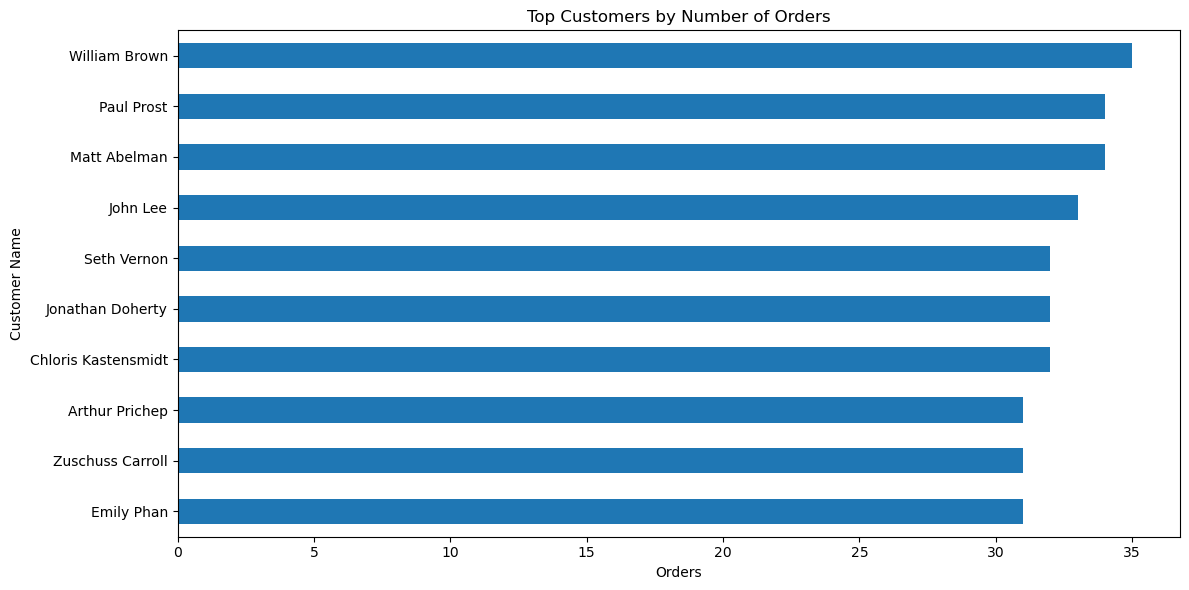

In [57]:
fig, ax = plt.subplots(figsize=(12,6))

customer_orders.sort_values().plot(
    kind='barh',
    ax=ax
)

ax.set_title("Top Customers by Number of Orders")
ax.set_xlabel("Orders")

plt.tight_layout()

fig.savefig("images/top_customers_orders.png", dpi=300)

plt.show()

### Insight

Customers placing frequent orders represent loyal buyers. Retaining these customers through personalized offers and loyalty programs can improve long-term revenue.

In [58]:
# 16: Orders by Customer Segment
segment_count = df['Segment'].value_counts()

segment_count

Segment
Consumer       5101
Corporate      2953
Home Office    1746
Name: count, dtype: int64

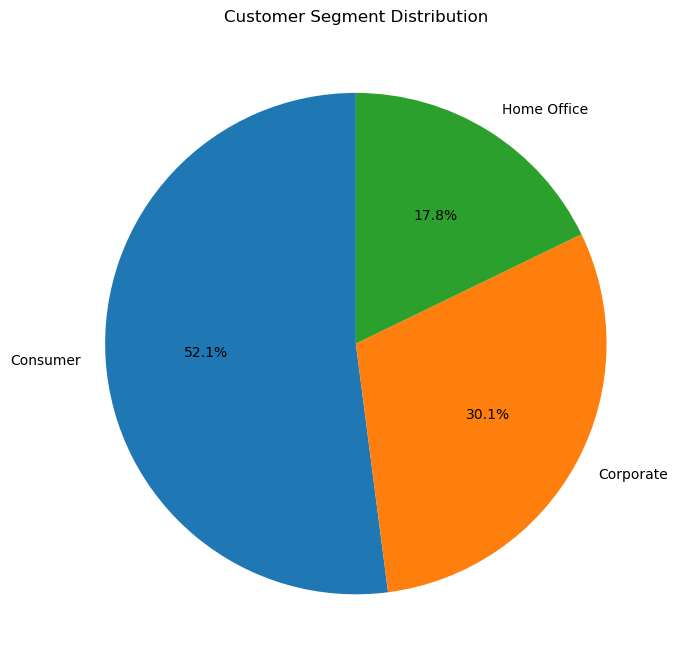

In [59]:
fig, ax = plt.subplots(figsize=(7,7))

ax.pie(
    segment_count,
    labels=segment_count.index,
    autopct='%1.1f%%',
    startangle=90
)

ax.set_title("Customer Segment Distribution")

plt.tight_layout()

fig.savefig("images/customer_segment_distribution.png", dpi=300)

plt.show()

### Insight

The Consumer segment represents the largest share of customers, highlighting its importance for business growth and customer engagement strategies.

In [60]:
# 17: Orders by Ship Mode

ship_orders = df['Ship Mode'].value_counts()

ship_orders

Ship Mode
Standard Class    5859
Second Class      1902
First Class       1501
Same Day           538
Name: count, dtype: int64

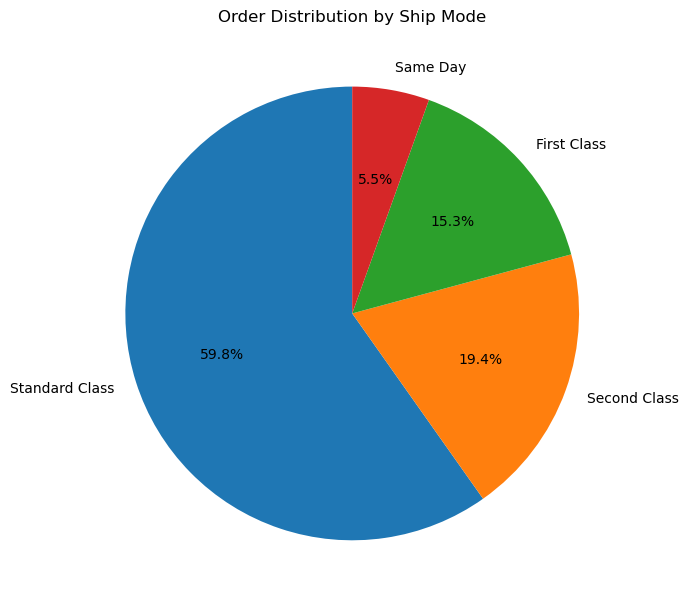

In [61]:
fig, ax = plt.subplots(figsize=(7,7))

ax.pie(
    ship_orders,
    labels=ship_orders.index,
    autopct='%1.1f%%',
    startangle=90
)

ax.set_title("Order Distribution by Ship Mode")

plt.tight_layout()

fig.savefig("images/ship_mode_distribution.png", dpi=300)

plt.show()

### Insight

Standard Class is the preferred shipping option, indicating that most customers prioritize economical delivery over faster shipping methods.